<a href="https://colab.research.google.com/github/mullinskatie7-source/College/blob/programming-for-engineers-python/Katherine_Mullins_HeightVSAge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Markdown
# Height vs Age
**Engineer:** Katherine Mullins

**Completion Date:** 06/27/2026

**Class:** EGN3214

**Assignment #:** 6 Discussion

**Tool Used:** Colab / Python

## Problem Description

I uploaded the Lancet Height vs. Age dataset from NCD-RisC to a code that I had chatGPT create. I wanted it to be a beginner-friendly Python script for Google Colab that reads the CSV file, displays the column names, and creates clear graphs showing average height versus age for boys and girls.


## Methodology

Claude Sonnet 3.7 generated a proposed data-visualization project that included scripts for plotting height by age, height trends over time, heatmaps, growth-rate comparisons, and interactive visualizations. The response recommended using Python libraries including pandas, NumPy, Matplotlib, Seaborn, and Plotly. It also described possible observations from the dataset, such as different growth patterns between boys and girls and changes in height across years.

I asked AI to show all of these graphs and the interactive visualization to challenge chatGPT and see if it could successfully generate a code that could output that.

LANCET HEIGHT VS. AGE DATASET VISUALIZATION

Please upload the file: NCD_RisC_Lancet_2020_height_child_adolescent_global.csv
Click 'Choose Files' and select the CSV file.



Saving NCD_RisC_Lancet_2020_height_child_adolescent_global.csv to NCD_RisC_Lancet_2020_height_child_adolescent_global.csv

✅ File uploaded: NCD_RisC_Lancet_2020_height_child_adolescent_global.csv

📊 Dataset shape: (1050, 7) rows x 7 columns

📋 Column names:
['Sex', 'Year', 'Age group', 'Mean height', 'Mean height lower 95% uncertainty interval', 'Mean height upper 95% uncertainty interval', 'Mean height standard error']

🔍 First 5 rows:
    Sex  Year  Age group  Mean height  \
0  Boys  1985          5   105.649052   
1  Boys  1985          6   111.635352   
2  Boys  1985          7   117.189491   
3  Boys  1985          8   122.438103   
4  Boys  1985          9   127.499794   

   Mean height lower 95% uncertainty interval  \
0                                  105.159635   
1                                  111.190655   
2                                  116.778453   
3                                  122.054426   
4                                  127.131517   

   Mean height up

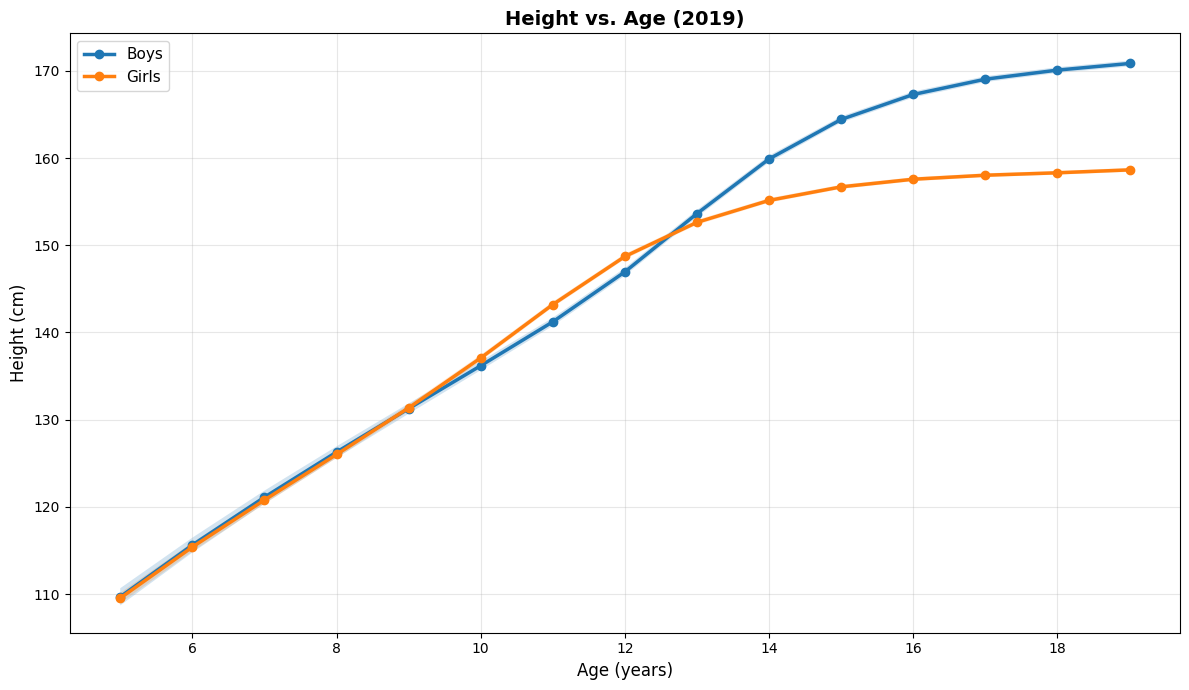


2️⃣ Creating Height Trends Over Time plot (Age 19)...


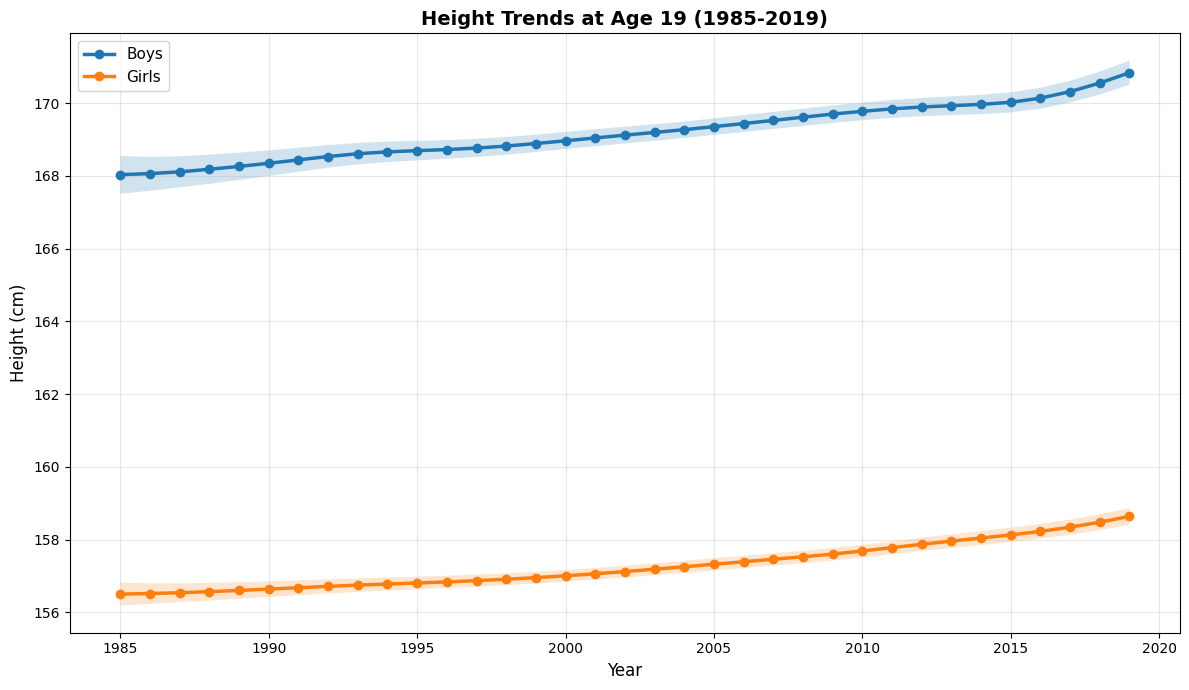


3️⃣ Creating Heatmap for Boys...


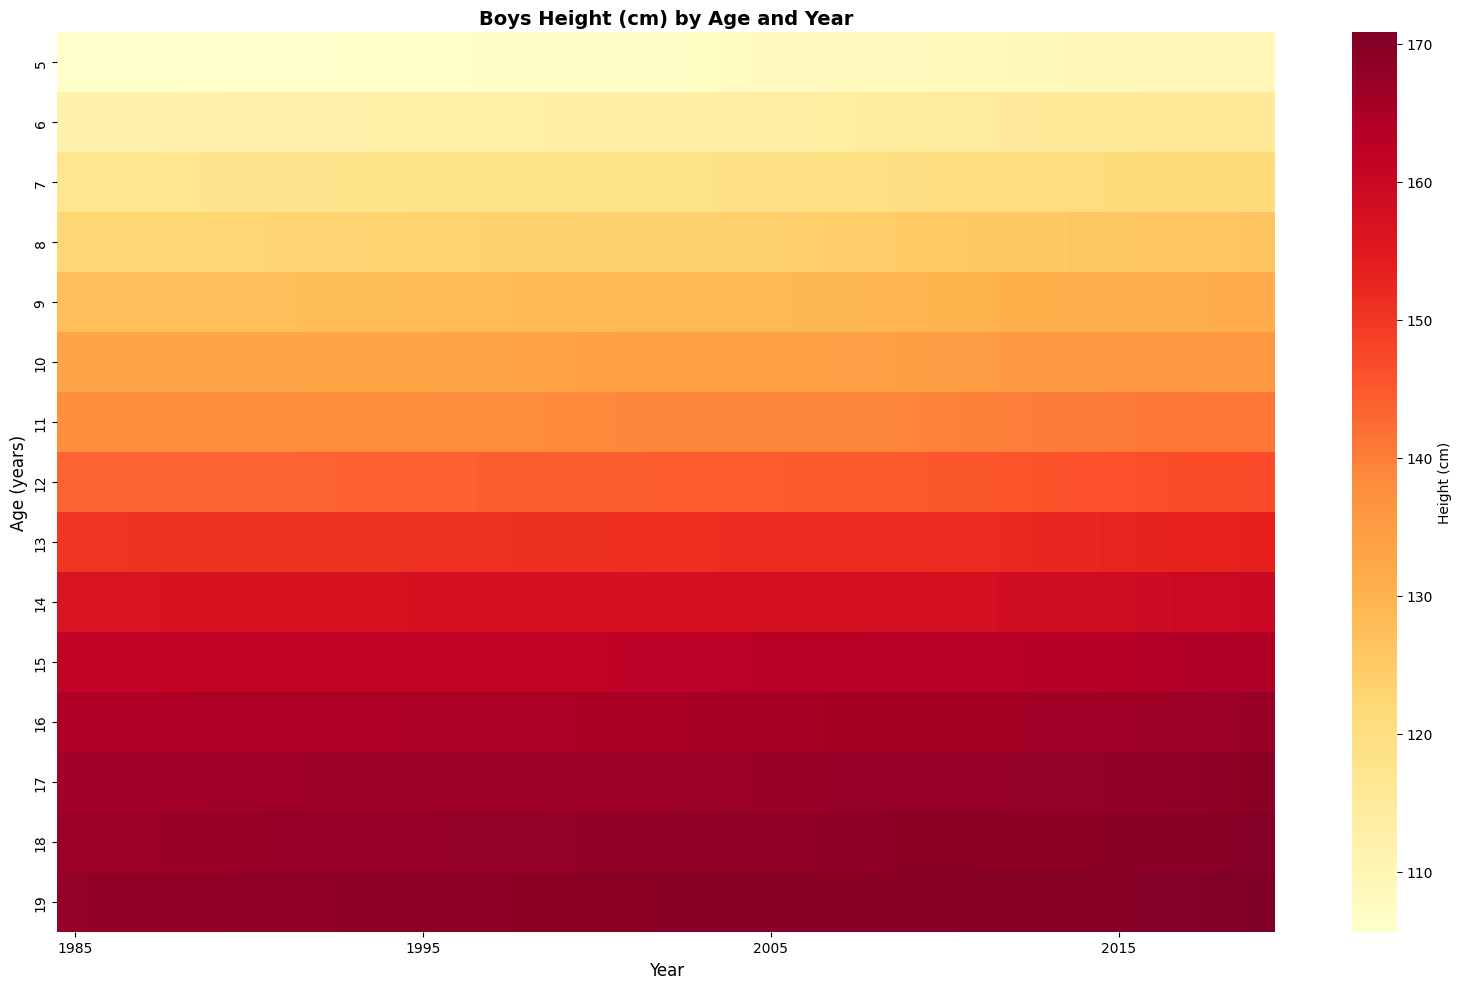


4️⃣ Creating Heatmap for Girls...


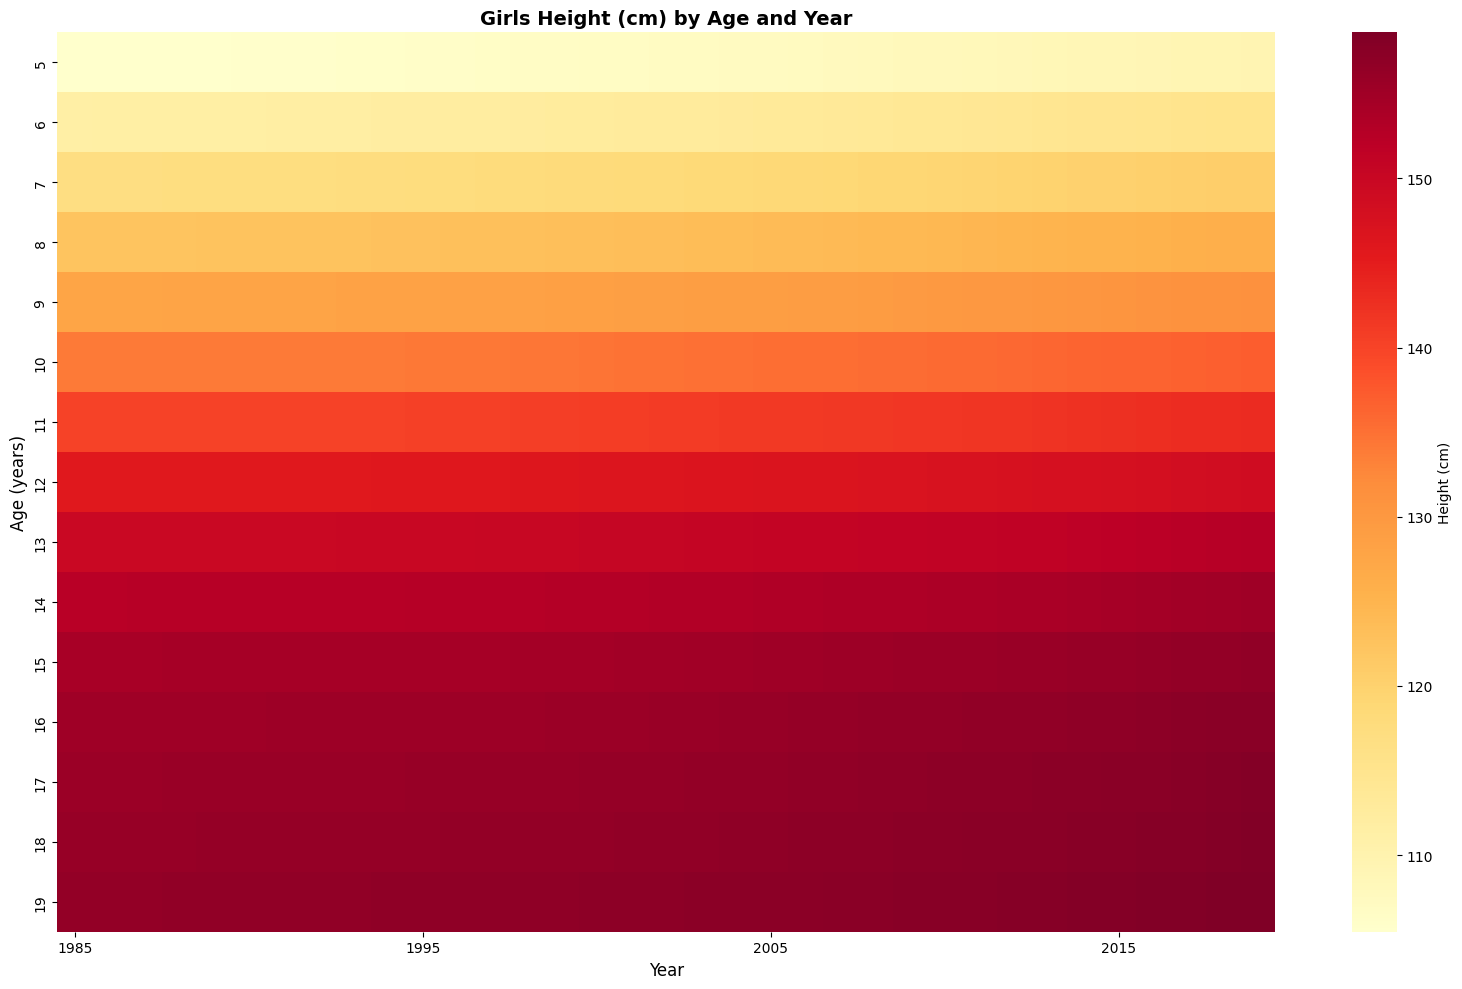


5️⃣ Creating Growth Rate Comparison...


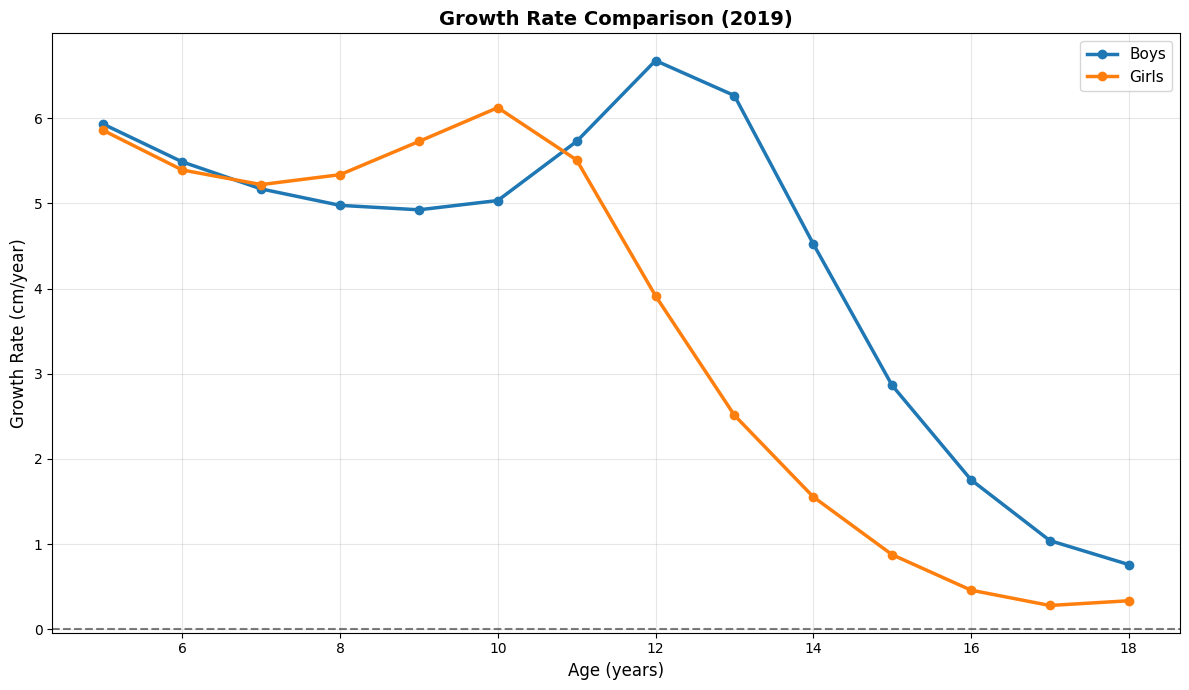


6️⃣ Creating Sex Difference Analysis...


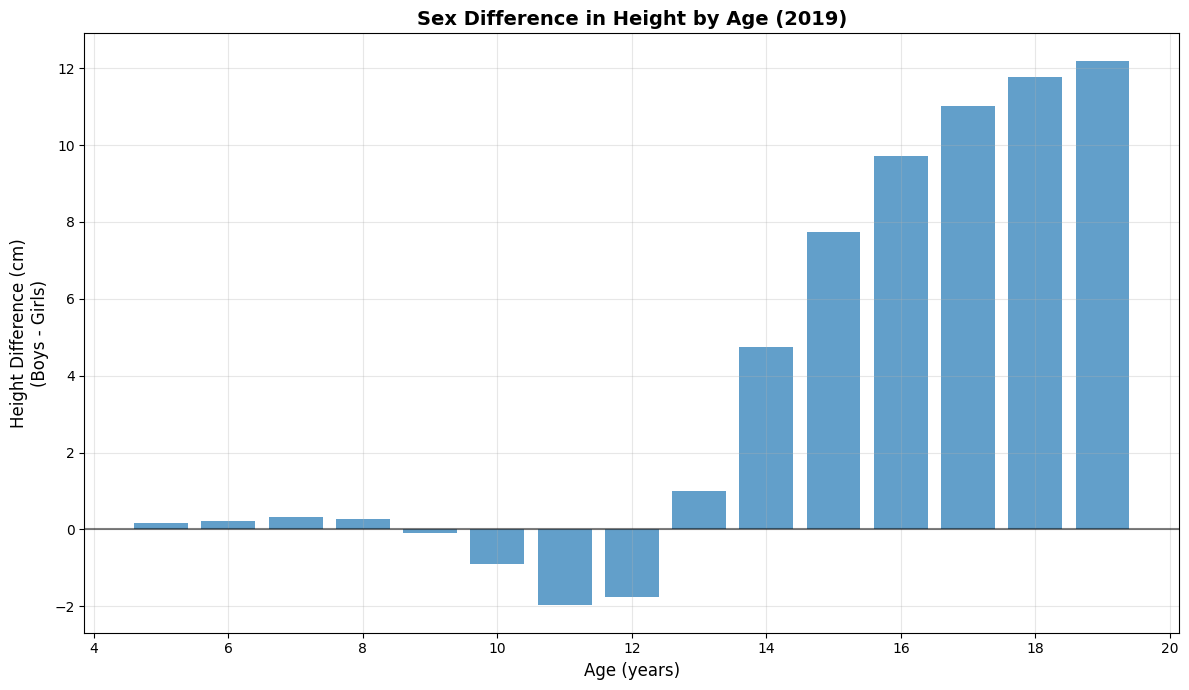


7️⃣ Creating Interactive Visualizations...



8️⃣ Calculating Engineering Design Percentiles...

📐 Engineering Design Percentiles (cm):
------------------------------------------------------------
Group                1st        5th        50th       95th       99th      
------------------------------------------------------------
Boys Age 19 (2019)      170.4     170.6     170.8     171.1     171.2
Girls Age 19 (2019)      158.4     158.4     158.6     158.8     158.9
Boys Age 15 (2019)      164.0     164.1     164.4     164.7     164.8
Girls Age 15 (2019)      156.4     156.5     156.7     156.9     157.0
------------------------------------------------------------

KEY FINDINGS

📊 Global Average Heights:
  Boys (1985, age 19): 168.0 cm
  Boys (2019, age 19): 170.8 cm → +2.8 cm
  Girls (1985, age 19): 156.5 cm
  Girls (2019, age 19): 158.6 cm → +2.1 cm

📈 Growth Trends:
  Boys - Girls difference (2019, age 19): 12.2 cm
  Boys - Girls difference (1985, age 19): 11.5 cm

✅ ALL VISUALIZATIONS COMPLETE!
📁 Files saved as PNG images

In [1]:
# ============================================================================
# Lancet Height vs. Age Dataset Visualization
# Complete Google Colab Script
# Dataset: NCD-RisC Lancet 2020 - Child and Adolescent Height
# ============================================================================

# Step 1: Install required packages (uncomment if needed)
# !pip install plotly -q

# Step 2: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from google.colab import files, drive
import warnings
warnings.filterwarnings('ignore')

# Step 3: Mount Google Drive (optional - for loading data from Drive)
# drive.mount('/content/drive')

# Step 4: Upload the dataset
print("="*60)
print("LANCET HEIGHT VS. AGE DATASET VISUALIZATION")
print("="*60)
print("\nPlease upload the file: NCD_RisC_Lancet_2020_height_child_adolescent_global.csv")
print("Click 'Choose Files' and select the CSV file.\n")

# Upload file
uploaded = files.upload()

# Get the filename
filename = list(uploaded.keys())[0]
print(f"\n✅ File uploaded: {filename}")

# Step 5: Load the dataset
df = pd.read_csv(filename)
print(f"\n📊 Dataset shape: {df.shape} rows x {df.shape[1]} columns")
print("\n📋 Column names:")
print(df.columns.tolist())

print("\n🔍 First 5 rows:")
print(df.head())

print("\n📈 Basic Statistics:")
print(df.describe())

# Step 6: Clean and prepare data
df_clean = df.dropna()
print(f"\n✅ Data cleaned: {len(df_clean)} rows remaining")

# Step 7: Create visualizations
print("\n" + "="*60)
print("GENERATING VISUALIZATIONS")
print("="*60)

# ----------------------------------------------------------------------------
# Visualization 1: Height by Age (2019)
# ----------------------------------------------------------------------------
print("\n1️⃣ Creating Height by Age plot (2019)...")

fig, ax = plt.subplots(figsize=(12, 7))

for sex in ['Boys', 'Girls']:
    data = df_clean[(df_clean['Year'] == 2019) & (df_clean['Sex'] == sex)]
    ax.plot(data['Age group'], data['Mean height'],
            marker='o', linewidth=2.5, label=sex)

    # Add uncertainty bands
    ax.fill_between(data['Age group'],
                    data['Mean height lower 95% uncertainty interval'],
                    data['Mean height upper 95% uncertainty interval'],
                    alpha=0.2)

ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Height (cm)', fontsize=12)
ax.set_title('Height vs. Age (2019)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('height_by_age_2019.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------------
# Visualization 2: Height Trends Over Time (Age 19)
# ----------------------------------------------------------------------------
print("\n2️⃣ Creating Height Trends Over Time plot (Age 19)...")

fig, ax = plt.subplots(figsize=(12, 7))

for sex in ['Boys', 'Girls']:
    data = df_clean[(df_clean['Age group'] == 19) & (df_clean['Sex'] == sex)]
    ax.plot(data['Year'], data['Mean height'],
            marker='o', linewidth=2.5, label=sex)

    # Add uncertainty bands
    ax.fill_between(data['Year'],
                    data['Mean height lower 95% uncertainty interval'],
                    data['Mean height upper 95% uncertainty interval'],
                    alpha=0.2)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Height (cm)', fontsize=12)
ax.set_title('Height Trends at Age 19 (1985-2019)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('height_trends_age19.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------------
# Visualization 3: Heatmap - Boys Height by Age and Year
# ----------------------------------------------------------------------------
print("\n3️⃣ Creating Heatmap for Boys...")

pivot_boys = df_clean[df_clean['Sex'] == 'Boys'].pivot_table(
    values='Mean height',
    index='Age group',
    columns='Year'
)

plt.figure(figsize=(16, 10))
sns.heatmap(pivot_boys, cmap='YlOrRd',
            cbar_kws={'label': 'Height (cm)'},
            xticklabels=10)
plt.title('Boys Height (cm) by Age and Year', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Age (years)', fontsize=12)
plt.tight_layout()
plt.savefig('heatmap_boys.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------------
# Visualization 4: Heatmap - Girls Height by Age and Year
# ----------------------------------------------------------------------------
print("\n4️⃣ Creating Heatmap for Girls...")

pivot_girls = df_clean[df_clean['Sex'] == 'Girls'].pivot_table(
    values='Mean height',
    index='Age group',
    columns='Year'
)

plt.figure(figsize=(16, 10))
sns.heatmap(pivot_girls, cmap='YlOrRd',
            cbar_kws={'label': 'Height (cm)'},
            xticklabels=10)
plt.title('Girls Height (cm) by Age and Year', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Age (years)', fontsize=12)
plt.tight_layout()
plt.savefig('heatmap_girls.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------------
# Visualization 5: Growth Rate Comparison
# ----------------------------------------------------------------------------
print("\n5️⃣ Creating Growth Rate Comparison...")

def calculate_growth_rate(data):
    data = data.sort_values('Age group')
    growth_rates = []
    for i in range(len(data) - 1):
        rate = (data.iloc[i+1]['Mean height'] - data.iloc[i]['Mean height']) / 1
        growth_rates.append(rate)
    return np.array(growth_rates)

fig, ax = plt.subplots(figsize=(12, 7))

for sex in ['Boys', 'Girls']:
    data = df_clean[(df_clean['Year'] == 2019) & (df_clean['Sex'] == sex)]
    rates = calculate_growth_rate(data)
    ages = data['Age group'].values[:-1]
    ax.plot(ages, rates, marker='o', linewidth=2.5, label=sex)

ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Growth Rate (cm/year)', fontsize=12)
ax.set_title('Growth Rate Comparison (2019)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('growth_rates_2019.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------------
# Visualization 6: Sex Difference Analysis
# ----------------------------------------------------------------------------
print("\n6️⃣ Creating Sex Difference Analysis...")

# Merge boys and girls data for comparison
boys_2019 = df_clean[(df_clean['Sex'] == 'Boys') & (df_clean['Year'] == 2019)]
girls_2019 = df_clean[(df_clean['Sex'] == 'Girls') & (df_clean['Year'] == 2019)]
merged = pd.merge(boys_2019, girls_2019, on='Age group', suffixes=('_boys', '_girls'))
merged['height_difference'] = merged['Mean height_boys'] - merged['Mean height_girls']

fig, ax = plt.subplots(figsize=(12, 7))
ax.bar(merged['Age group'], merged['height_difference'], alpha=0.7)
ax.axhline(y=0, color='black', linestyle='-', alpha=0.5)
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Height Difference (cm)\n(Boys - Girls)', fontsize=12)
ax.set_title('Sex Difference in Height by Age (2019)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sex_difference_2019.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------------
# Visualization 7: Interactive Plotly Visualizations
# ----------------------------------------------------------------------------
print("\n7️⃣ Creating Interactive Visualizations...")

# Interactive 1: Height by Age with Year Slider
fig1 = px.line(df_clean, x='Age group', y='Mean height', color='Sex',
               animation_frame='Year', range_x=[4, 20],
               title='Interactive: Height vs. Age by Year',
               labels={'Age group': 'Age (years)', 'Mean height': 'Height (cm)'},
               hover_data=['Mean height lower 95% uncertainty interval',
                          'Mean height upper 95% uncertainty interval'])
fig1.update_layout(height=600)
fig1.show()

# Interactive 2: 3D Surface Plot
pivot_3d = df_clean[df_clean['Sex'] == 'Boys'].pivot_table(
    values='Mean height',
    index='Age group',
    columns='Year'
)

fig2 = go.Figure(data=[go.Surface(z=pivot_3d.values,
                                   x=pivot_3d.columns,
                                   y=pivot_3d.index,
                                   colorscale='Viridis')])
fig2.update_layout(title='3D Surface: Boys Height by Age and Year',
                   scene=dict(xaxis_title='Year',
                             yaxis_title='Age (years)',
                             zaxis_title='Height (cm)'),
                   height=600)
fig2.show()

# ----------------------------------------------------------------------------
# Visualization 8: Engineering Design Percentiles
# ----------------------------------------------------------------------------
print("\n8️⃣ Calculating Engineering Design Percentiles...")

def calculate_design_percentiles(df, sex='Boys', year=2019, age=19):
    """Calculate design-relevant percentiles for engineering applications"""
    data = df[(df['Sex'] == sex) & (df['Year'] == year) & (df['Age group'] == age)]

    if len(data) == 0:
        print(f"No data found for {sex} age {age} in {year}")
        return None

    mean = data['Mean height'].values[0]
    se = data['Mean height standard error'].values[0]

    # Calculate percentiles (assuming normal distribution)
    percentiles = {
        '1st (minimum design)': mean - 2.33 * se,
        '5th (small adult)': mean - 1.645 * se,
        '50th (average)': mean,
        '95th (tall adult)': mean + 1.645 * se,
        '99th (maximum design)': mean + 2.33 * se
    }

    return percentiles

# Calculate for different groups
groups = [
    ('Boys', 2019, 19),
    ('Girls', 2019, 19),
    ('Boys', 2019, 15),
    ('Girls', 2019, 15),
]

print("\n📐 Engineering Design Percentiles (cm):")
print("-" * 60)
print(f"{'Group':<20} {'1st':<10} {'5th':<10} {'50th':<10} {'95th':<10} {'99th':<10}")
print("-" * 60)

for sex, year, age in groups:
    p = calculate_design_percentiles(df_clean, sex, year, age)
    if p:
        print(f"{sex} Age {age} ({year})", end=" ")
        print(f"{p['1st (minimum design)']:.1f}".rjust(10), end="")
        print(f"{p['5th (small adult)']:.1f}".rjust(10), end="")
        print(f"{p['50th (average)']:.1f}".rjust(10), end="")
        print(f"{p['95th (tall adult)']:.1f}".rjust(10), end="")
        print(f"{p['99th (maximum design)']:.1f}".rjust(10))

print("-" * 60)

# ----------------------------------------------------------------------------
# Summary Statistics
# ----------------------------------------------------------------------------
print("\n" + "="*60)
print("KEY FINDINGS")
print("="*60)

# Key statistics
boys_2019_19 = df_clean[(df_clean['Sex'] == 'Boys') & (df_clean['Year'] == 2019) & (df_clean['Age group'] == 19)]
girls_2019_19 = df_clean[(df_clean['Sex'] == 'Girls') & (df_clean['Year'] == 2019) & (df_clean['Age group'] == 19)]

boys_1985_19 = df_clean[(df_clean['Sex'] == 'Boys') & (df_clean['Year'] == 1985) & (df_clean['Age group'] == 19)]
girls_1985_19 = df_clean[(df_clean['Sex'] == 'Girls') & (df_clean['Year'] == 1985) & (df_clean['Age group'] == 19)]

print(f"\n📊 Global Average Heights:")
print(f"  Boys (1985, age 19): {boys_1985_19['Mean height'].values[0]:.1f} cm")
print(f"  Boys (2019, age 19): {boys_2019_19['Mean height'].values[0]:.1f} cm → +{(boys_2019_19['Mean height'].values[0] - boys_1985_19['Mean height'].values[0]):.1f} cm")
print(f"  Girls (1985, age 19): {girls_1985_19['Mean height'].values[0]:.1f} cm")
print(f"  Girls (2019, age 19): {girls_2019_19['Mean height'].values[0]:.1f} cm → +{(girls_2019_19['Mean height'].values[0] - girls_1985_19['Mean height'].values[0]):.1f} cm")

print(f"\n📈 Growth Trends:")
print(f"  Boys - Girls difference (2019, age 19): {(boys_2019_19['Mean height'].values[0] - girls_2019_19['Mean height'].values[0]):.1f} cm")
print(f"  Boys - Girls difference (1985, age 19): {(boys_1985_19['Mean height'].values[0] - girls_1985_19['Mean height'].values[0]):.1f} cm")

print("\n" + "="*60)
print("✅ ALL VISUALIZATIONS COMPLETE!")
print("📁 Files saved as PNG images in the current directory")
print("="*60)

# Option to download all images
print("\n💡 To download all images, navigate to the Files panel in Colab")
print("   and download the PNG files individually.")